In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [2]:
capm_data = pd.read_csv(
    "../data/processed/capm_excess_returns.csv",
    index_col=0,
    parse_dates=True
)
capm_data.head()

,CBA,NAB,WBC,ANZ,MQG,Market_Excess_Return
Date,,,,,,
2001-08-30,-0.019135,-0.012403,-0.010019,0.000574,-0.004485,-0.007522
2001-08-31,-0.023296,-0.023148,-0.014651,-0.003734,-0.018748,-0.014590
2001-09-03,0.005054,-0.129712,0.013758,0.019937,0.016904,-0.000106
2001-09-04,0.010552,0.025758,0.000515,0.009150,0.018090,0.004102
2001-09-05,-0.011152,0.008854,-0.008689,-0.035891,0.019766,0.000411


In [3]:
bank_columns = ["CBA", "NAB", "WBC", "ANZ", "MQG"]
market_column = "Market_Excess_Return"
print("Banks:", bank_columns)
print("Market variable:", market_column)

Banks: ['CBA', 'NAB', 'WBC', 'ANZ', 'MQG']
Market variable: Market_Excess_Return


In [4]:
diagnostic_models = {}
for bank in bank_columns:
    y = capm_data[bank]
    X = capm_data[market_column]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    diagnostic_models[bank] = model

print("All CAPM diagnostic models estimated successfully.")

All CAPM diagnostic models estimated successfully.


In [5]:
residuals = pd.DataFrame()
for bank in bank_columns:
    residuals[bank] = diagnostic_models[bank].resid
residuals.head()

,CBA,NAB,WBC,ANZ,MQG
Date,,,,,
2001-08-30,-0.011580,-0.003906,-0.001833,0.009079,0.005840
2001-08-31,-0.008454,-0.006699,0.001296,0.012730,0.001484
2001-09-03,0.004963,-0.129558,0.013800,0.020091,0.016835
2001-09-04,0.006122,0.021177,-0.004065,0.004565,0.012121
2001-09-05,-0.011776,0.008426,-0.009215,-0.036320,0.018971


In [6]:
print("RESIDUALS SHAPE:")
print(residuals.shape)

print("\nMISSING VALUES:")
print(residuals.isnull().sum())

print("\nRESIDUAL SUMMARY:")
print(residuals.describe())

RESIDUALS SHAPE:
(6293, 5)

MISSING VALUES:
CBA    0
NAB    0
WBC    0
ANZ    0
MQG    0
dtype: int64

RESIDUAL SUMMARY:
                CBA           NAB           WBC           ANZ           MQG
count  6.293000e+03  6.293000e+03  6.293000e+03  6.293000e+03  6.293000e+03
mean   2.028852e-19  3.352016e-19 -2.646329e-20  1.852430e-19  3.748965e-19
std    9.281387e-03  1.018434e-02  9.938374e-03  1.031791e-02  1.505913e-02
min   -9.975347e-02 -1.295577e-01 -9.568430e-02 -9.825673e-02 -1.983915e-01
25%   -4.428028e-03 -4.692023e-03 -5.116730e-03 -4.798993e-03 -6.632307e-03
50%   -4.227181e-05 -7.463553e-05 -5.496722e-05 -4.047448e-05 -2.927059e-04
75%    4.457711e-03  4.808982e-03  4.897391e-03  4.644775e-03  6.357901e-03
max    9.479296e-02  1.254611e-01  8.112709e-02  9.822928e-02  3.181116e-01


In [7]:
print("MEAN RESIDUALS:")
print(residuals.mean())

MEAN RESIDUALS:
CBA    2.028852e-19
NAB    3.352016e-19
WBC   -2.646329e-20
ANZ    1.852430e-19
MQG    3.748965e-19
dtype: float64


In [8]:
print(residuals.describe())
print(residuals.mean())

                CBA           NAB           WBC           ANZ           MQG
count  6.293000e+03  6.293000e+03  6.293000e+03  6.293000e+03  6.293000e+03
mean   2.028852e-19  3.352016e-19 -2.646329e-20  1.852430e-19  3.748965e-19
std    9.281387e-03  1.018434e-02  9.938374e-03  1.031791e-02  1.505913e-02
min   -9.975347e-02 -1.295577e-01 -9.568430e-02 -9.825673e-02 -1.983915e-01
25%   -4.428028e-03 -4.692023e-03 -5.116730e-03 -4.798993e-03 -6.632307e-03
50%   -4.227181e-05 -7.463553e-05 -5.496722e-05 -4.047448e-05 -2.927059e-04
75%    4.457711e-03  4.808982e-03  4.897391e-03  4.644775e-03  6.357901e-03
max    9.479296e-02  1.254611e-01  8.112709e-02  9.822928e-02  3.181116e-01
CBA    2.028852e-19
NAB    3.352016e-19
WBC   -2.646329e-20
ANZ    1.852430e-19
MQG    3.748965e-19
dtype: float64


In [9]:
heteroskedasticity_results = []
for bank in bank_columns:
    
    model = diagnostic_models[bank]
    
    # Breusch-Pagan test
    bp_test = het_breuschpagan(
        model.resid,
        model.model.exog
    )
    
    heteroskedasticity_results.append({
        "Bank": bank,
        "LM Statistic": bp_test[0],
        "LM p-value": bp_test[1],
        "F Statistic": bp_test[2],
        "F p-value": bp_test[3]
    })

heteroskedasticity_table = pd.DataFrame(
    heteroskedasticity_results
)
heteroskedasticity_table

,Bank,LM Statistic,LM p-value,F Statistic,F p-value
0,CBA,5.037726,0.024801,5.040160,0.024801
1,NAB,0.350696,0.553719,0.350605,0.553792
2,WBC,0.383175,0.535909,0.383076,0.535984
3,ANZ,4.774110,0.028891,4.776216,0.028892
4,MQG,1.203979,0.272528,1.203827,0.272600


In [10]:
heteroskedasticity_table["Conclusion"] = heteroskedasticity_table[
    "LM p-value"
].apply(
    lambda p: "Heteroskedasticity detected"
    if p < 0.05
    else "No significant heteroskedasticity"
)
heteroskedasticity_table

,Bank,LM Statistic,LM p-value,F Statistic,F p-value,Conclusion
0,CBA,5.037726,0.024801,5.040160,0.024801,Heteroskedasticity detected
1,NAB,0.350696,0.553719,0.350605,0.553792,No significant heteroskedasticity
2,WBC,0.383175,0.535909,0.383076,0.535984,No significant heteroskedasticity
3,ANZ,4.774110,0.028891,4.776216,0.028892,Heteroskedasticity detected
4,MQG,1.203979,0.272528,1.203827,0.272600,No significant heteroskedasticity


In [11]:
autocorrelation_results = []
for bank in bank_columns:
    
    residual = diagnostic_models[bank].resid
    
    dw_statistic = durbin_watson(residual)
    
    autocorrelation_results.append({
        "Bank": bank,
        "Durbin_Watson": dw_statistic
    })
autocorrelation_table = pd.DataFrame(autocorrelation_results)
autocorrelation_table

,Bank,Durbin_Watson
0,CBA,1.937339
1,NAB,1.877200
2,WBC,1.924107
3,ANZ,1.922940
4,MQG,2.057142


In [12]:
normality_results = []
for bank in bank_columns:
    
    residual = diagnostic_models[bank].resid
    
    normality_results.append({
        "Bank": bank,
        "Skewness": stats.skew(residual),
        "Kurtosis": stats.kurtosis(residual),
        "Jarque_Bera_Statistic": stats.jarque_bera(residual).statistic,
        "Jarque_Bera_p_value": stats.jarque_bera(residual).pvalue
    })

normality_table = pd.DataFrame(normality_results)
normality_table

,Bank,Skewness,Kurtosis,Jarque_Bera_Statistic,Jarque_Bera_p_value
0,CBA,-0.215169,12.089545,38372.168874,0.0
1,NAB,0.005569,14.990254,58920.267086,0.0
2,WBC,0.077317,8.803371,20327.242660,0.0
3,ANZ,0.247453,9.796539,25228.928829,0.0
4,MQG,1.837098,48.925490,631188.763954,0.0


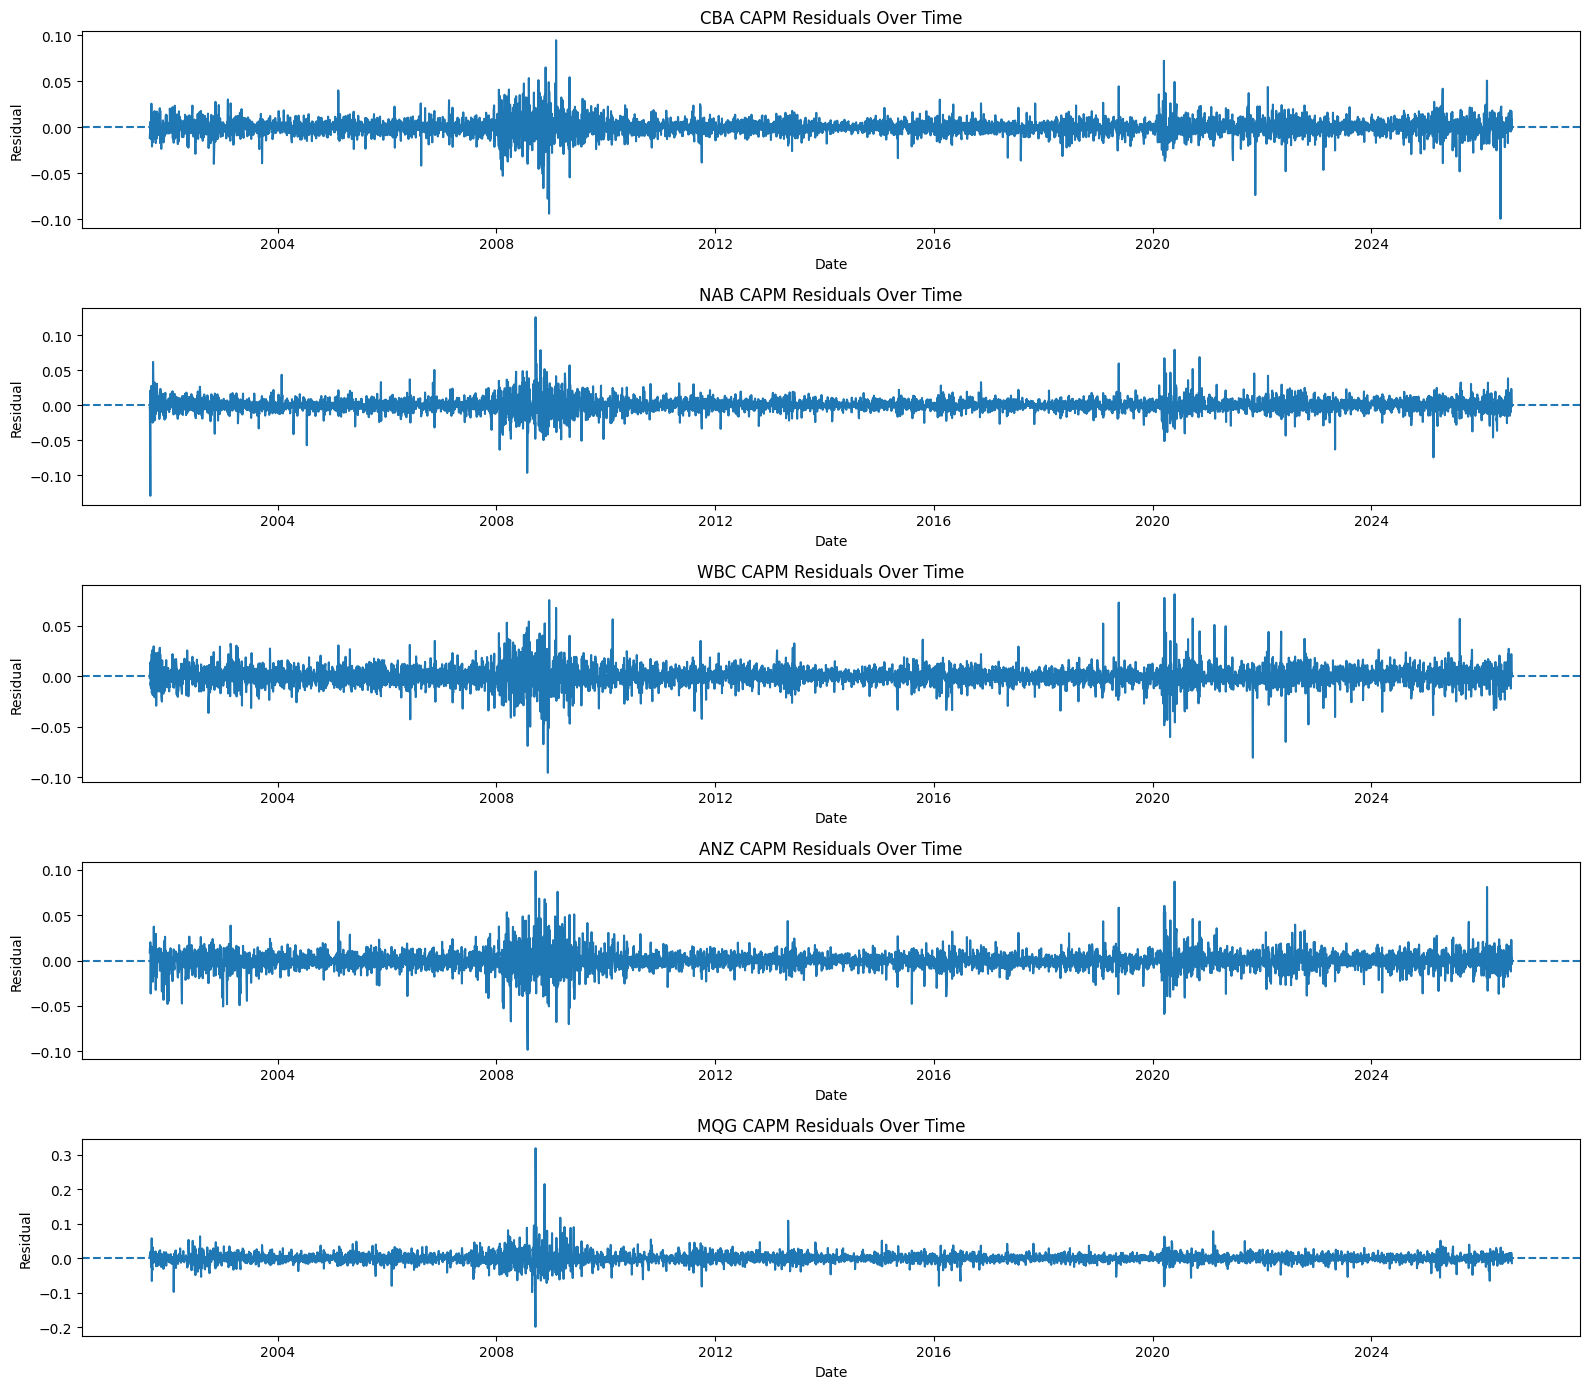

In [13]:
# Define the banks directly from the residuals DataFrame
banks_list = residuals.columns.tolist()

fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

for ax, bank in zip(axes, banks_list):

    ax.plot(residuals.index, residuals[bank])
    ax.axhline(0, linestyle="--")

    ax.set_title(f"{bank} CAPM Residuals Over Time")
    ax.set_ylabel("Residual")
    ax.tick_params(axis="x", labelbottom=True)
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

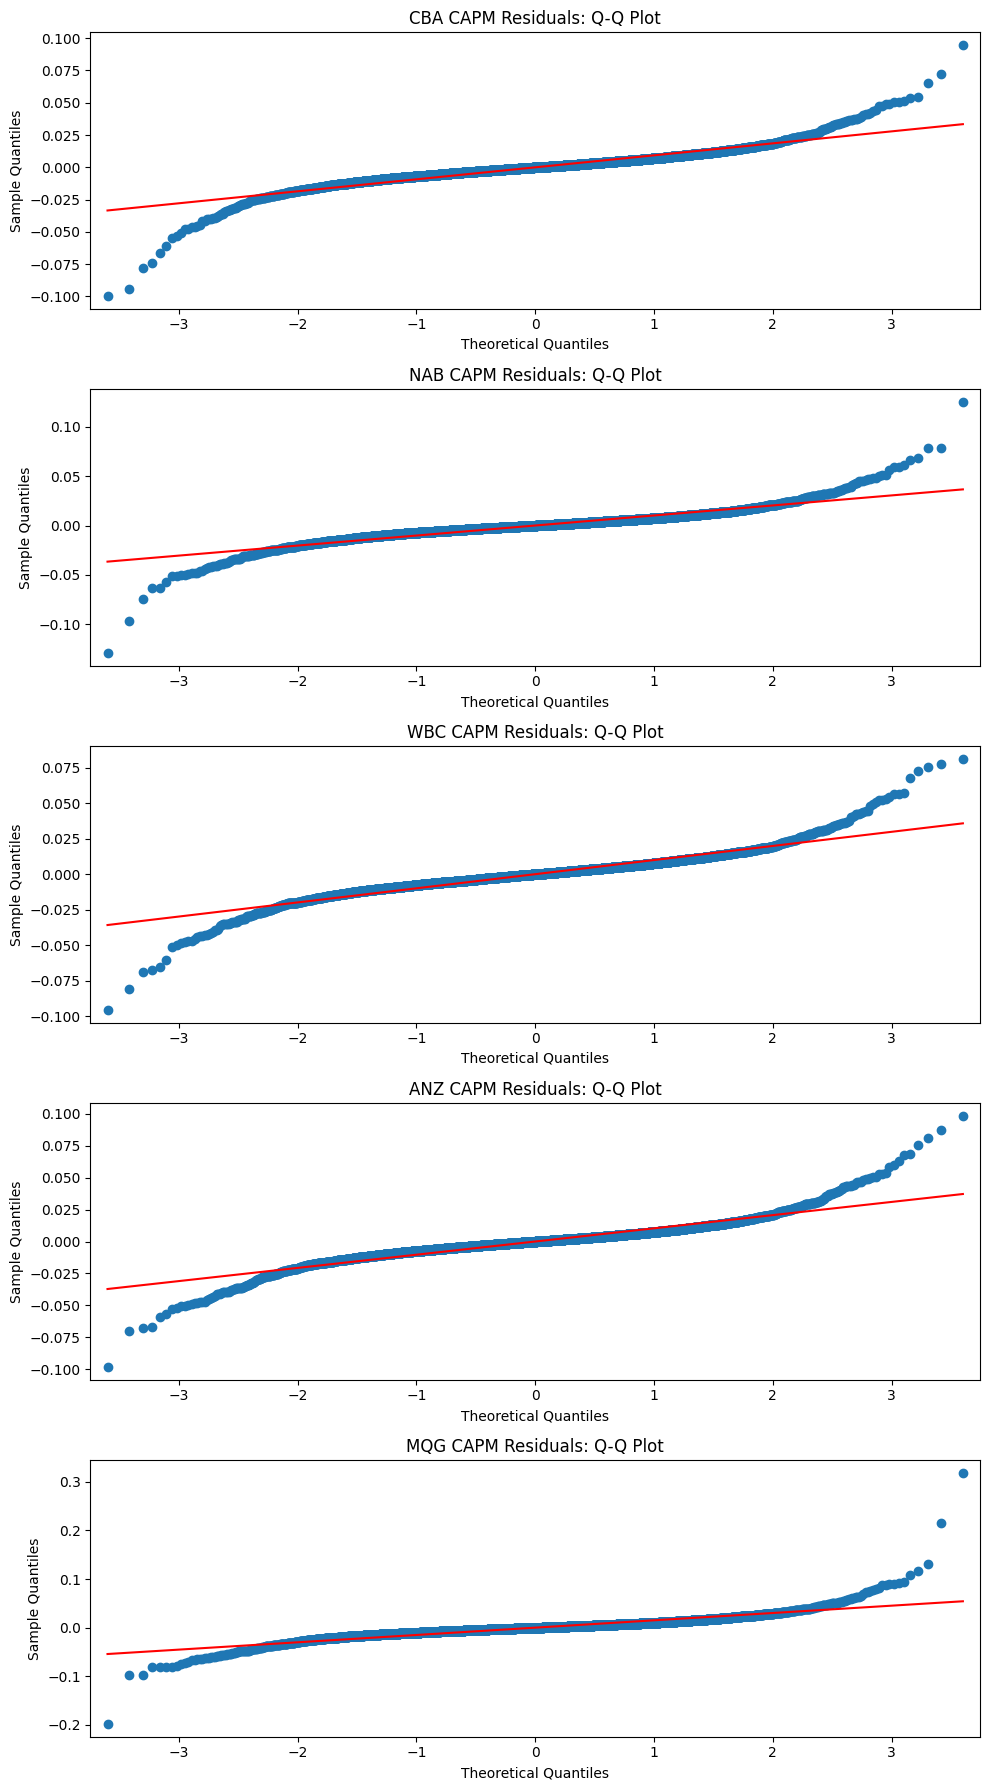

In [14]:
banks_list = residuals.columns.tolist()
fig, axes = plt.subplots(
    5,
    1,
    figsize=(10, 18)
)
for ax, bank in zip(axes, banks_list):

    sm.qqplot(
        residuals[bank],
        line="s",
        ax=ax
    )

    ax.set_title(f"{bank} CAPM Residuals: Q-Q Plot")
plt.tight_layout()
plt.show()

In [15]:
# Create final regression diagnostics summary table

diagnostics_summary = pd.DataFrame()
diagnostics_summary["Bank"] = heteroskedasticity_table["Bank"]
diagnostics_summary["BP_p_value"] = heteroskedasticity_table["LM p-value"]
diagnostics_summary["Heteroskedasticity"] = heteroskedasticity_table["Conclusion"]
diagnostics_summary["Durbin_Watson"] = autocorrelation_table["Durbin_Watson"]
diagnostics_summary["Autocorrelation"] = diagnostics_summary[
    "Durbin_Watson"
].apply(
    lambda x: (
        "No significant autocorrelation"
        if 1.5 <= x <= 2.5
        else "Potential autocorrelation"
    )
)
diagnostics_summary["JB_Statistic"] = normality_table[
    "Jarque_Bera_Statistic"
]

diagnostics_summary["JB_p_value"] = normality_table[
    "Jarque_Bera_p_value"
]
diagnostics_summary["Normality"] = diagnostics_summary[
    "JB_p_value"
].apply(
    lambda x: (
        "Non-normal residuals"
        if x < 0.05
        else "Approximately normal residuals"
    )
)
diagnostics_summary = diagnostics_summary.round(4)

diagnostics_summary

,Bank,BP_p_value,Heteroskedasticity,Durbin_Watson,Autocorrelation,JB_Statistic,JB_p_value,Normality
0,CBA,0.0248,Heteroskedasticity detected,1.9373,No significant autocorrelation,38372.1689,0.0,Non-normal residuals
1,NAB,0.5537,No significant heteroskedasticity,1.8772,No significant autocorrelation,58920.2671,0.0,Non-normal residuals
2,WBC,0.5359,No significant heteroskedasticity,1.9241,No significant autocorrelation,20327.2427,0.0,Non-normal residuals
3,ANZ,0.0289,Heteroskedasticity detected,1.9229,No significant autocorrelation,25228.9288,0.0,Non-normal residuals
4,MQG,0.2725,No significant heteroskedasticity,2.0571,No significant autocorrelation,631188.7640,0.0,Non-normal residuals
